In [1]:
import shap
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from models import *
from datasets import *

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

import reload_shap_plot

# 划分训练和测试集

In [2]:
dataset = BinaryDataset('Node123_loop_noisy')
n_buses = dataset.n_buses
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size], generator=torch.Generator().manual_seed(20))
feature_names = [f'Bus {i+1}' for i in range(1, n_buses + 1)]

# 初始化模型

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CnnClassifier().to(device)
# model = CnnClassifierPairwise().to(device)
# model = MLPClassifier(dataset.n_buses).to(device)
# model = TransformerClassifier(dataset.n_buses).to(device)
# model = LSTMClassifier(dataset.n_buses).to(device)

model.load_state_dict(torch.load('voltage_cnn_model.pth', weights_only=True))
model.eval()

CnnClassifier(
  (features): Sequential(
    (0): Conv1d(1, 32, kernel_size=(2,), stride=(1,), padding=(1,))
    (1): ReLU(inplace=True)
    (2): Conv1d(32, 64, kernel_size=(2,), stride=(1,), padding=(1,))
    (3): ReLU(inplace=True)
    (4): Conv1d(64, 128, kernel_size=(2,), stride=(1,), padding=(1,))
    (5): ReLU(inplace=True)
  )
  (classifier): Sequential(
    (0): LazyLinear(in_features=0, out_features=64, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [4]:
label_1_samples = []
label_0_samples = []
for data, label in train_dataset:
    if label.item() == 1:  # Filter label 1 samples
        label_1_samples.append(data)  # Convert to NumPy for SHAP
    else: 
        label_0_samples.append(data)

# Convert to NumPy array for SHAP compatibility
label_0_samples = np.array(label_0_samples)
label_1_samples = np.array(label_1_samples)

print(label_0_samples.shape)
print(label_1_samples.shape)

(800, 1, 122)
(800, 1, 122)


In [5]:
# Compute mean background from normal (label 0) samples
background_mean = label_0_samples.mean(0)  # Compute mean across samples
# background_mean = torch.tensor(np.zeros_like(background_mean)+0.1, dtype=torch.float32)  # Use zero mean as background

# Ensure at least (n_buses + 1) samples
n_buses = background_mean.shape[-1]
num_background_samples = n_buses + 1  # Ensure SHAP has enough samples

# Expand background by adding small Gaussian noise to the mean values
# background = background_mean.unsqueeze(0).repeat(num_background_samples, 1, 1)  # Repeat mean row [100,1,8]

# Convert to NumPy for SHAP
background = background_mean

""" Check this line of code """
background = np.tile(background, (2, 1))  # Expand background size *2

background.shape

(2, 122)

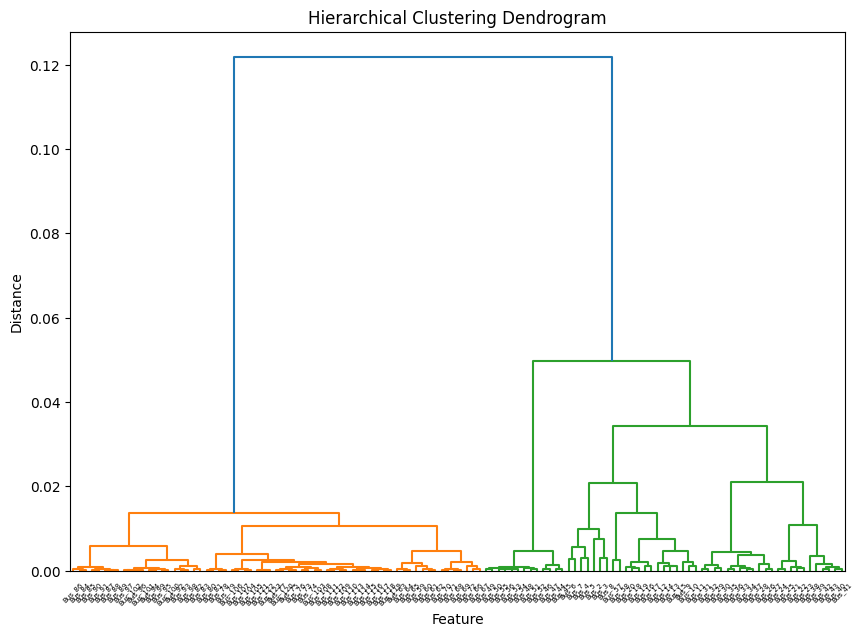

In [6]:
def get_matrix_from_data(data_normal, data_outage):
    # # Combine the two datasets
    # combined_data = pd.concat([data_normal, data_outage])
    combined_data = data_normal
    # combined_data = data_outage

    # Compute the correlation matrix
    corr_matrix = combined_data.corr()

    # Convert the correlation matrix to a distance matrix
    distance_matrix = 1 - corr_matrix

    # Perform hierarchical clustering
    Z = linkage(squareform(distance_matrix), method='average')
    return Z, corr_matrix

Z, corr_matrix = get_matrix_from_data(dataset.data_df, dataset.data_outage_df)

# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(Z, labels=corr_matrix.columns, leaf_rotation=45)
# dendrogram(Z, leaf_rotation=45)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Feature')
plt.ylabel('Distance')
plt.show()

In [7]:
instance = label_1_samples[0]
instance.shape

(1, 122)

In [8]:
def model_wrapper(x):
    x = torch.tensor(x, dtype=torch.float32).unsqueeze(1).to(device)
    with torch.no_grad():
        probability = torch.sigmoid(model(x))  # Convert logits to probabilities
        prediction = (probability > 0.5).float()  # Convert to binary labels
    return prediction.cpu().numpy().squeeze()

In [9]:
# Initialize SHAP Explainer
masker = shap.maskers.Partition(background)
masker.clustering = Z  # 强制使用你的 partition_tree
explainer = shap.PartitionExplainer(model_wrapper, masker, feature_names=feature_names)

2025-03-25 19:01:48.920589: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-25 19:01:48.926514: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742954508.934441    3750 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742954508.936823    3750 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-25 19:01:48.945230: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [10]:
model_wrapper(instance)

array(1., dtype=float32)

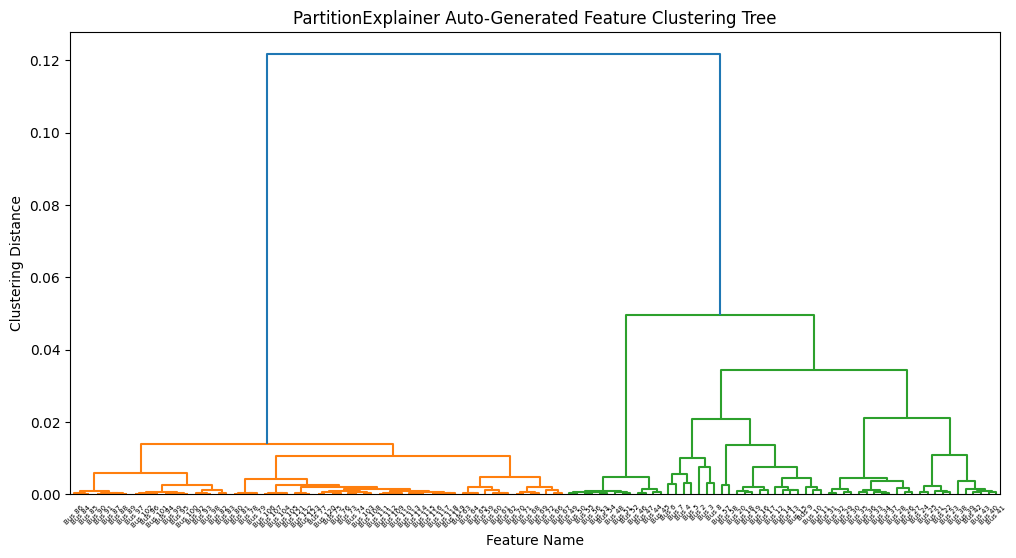

In [11]:
clustering_tree = explainer._clustering

if clustering_tree is not None:
    plt.figure(figsize=(12, 6))
    dendrogram(clustering_tree, labels=explainer.feature_names, leaf_rotation=45)
    plt.xlabel("Feature Name")
    plt.ylabel("Clustering Distance")
    plt.title("PartitionExplainer Auto-Generated Feature Clustering Tree")
    plt.show()
else:
    print("PartitionExplainer did not generate a clustering tree.")

In [12]:
shap_values = explainer(label_1_samples.squeeze())

PartitionExplainer explainer: 801it [00:31, 17.50it/s]                         


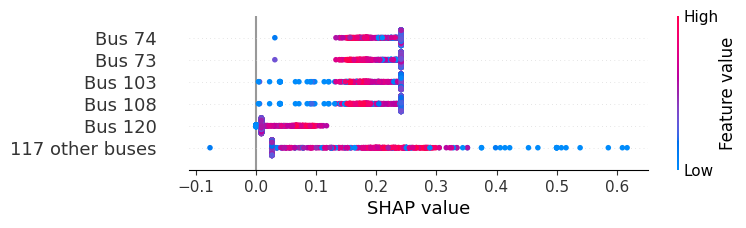

In [13]:
shap.plots.beeswarm(shap_values, max_display=6, plot_size=(7.4, 2))

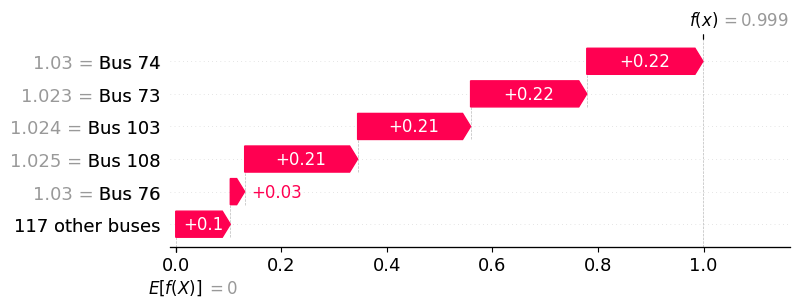

In [14]:
shap.plots.waterfall(shap_values.mean(0))

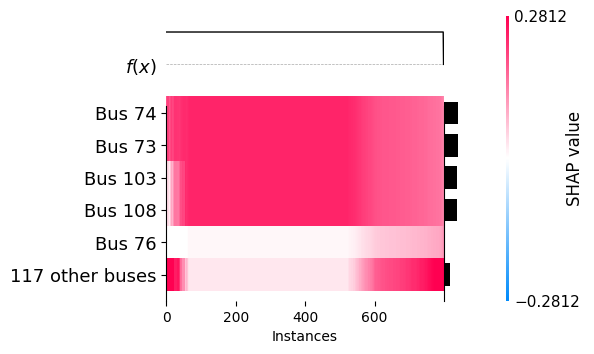

<Axes: xlabel='Instances'>

In [15]:
shap.plots.heatmap(shap_values, max_display=6)